# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

**A decision tree is essentially a flow chart that sorts the predictor values into subsets of predicted values.**

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

**The depth of a decision tree is how many sequential decisions can be made before reaching a conclusion. If a tree is too deep, the data will be overfitted. If its not deep enough, the data will be underfitted.**

**Task4:**

How are BART models similar and different from a decision tree?

**While both BART models and decision trees use nodes to make predictions. However, a decision tree uses one tree to fit data, while BART models use multiple.**

**Task5**:

Why would we use a BART model instead of a decision tree?

**To have higher predictive accuracy and prevent overfitting.**

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [3]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [4]:
print(penguins)

       species     island  bill_length  bill_depth  flipper_length  body_mass  \
0       Adelie  Torgersen         3.91        1.87            18.1      3.750   
1       Adelie  Torgersen         3.95        1.74            18.6      3.800   
2       Adelie  Torgersen         4.03        1.80            19.5      3.250   
4       Adelie  Torgersen         3.67        1.93            19.3      3.450   
5       Adelie  Torgersen         3.93        2.06            19.0      3.650   
..         ...        ...          ...         ...             ...        ...   
339  Chinstrap      Dream         5.58        1.98            20.7      4.000   
340  Chinstrap      Dream         4.35        1.81            20.2      3.400   
341  Chinstrap      Dream         4.96        1.82            19.3      3.775   
342  Chinstrap      Dream         5.08        1.90            21.0      4.100   
343  Chinstrap      Dream         5.02        1.87            19.8      3.775   

        sex  year  
0      

In [17]:
X = penguins[["flipper_length", "bill_depth", "bill_length"]]
Y = penguins["body_mass"].to_numpy()

In [ ]:
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s',1000)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_penguins = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_penguins,model_penguins, extend_inferencedata=True)

<Axes: xlabel='y'>

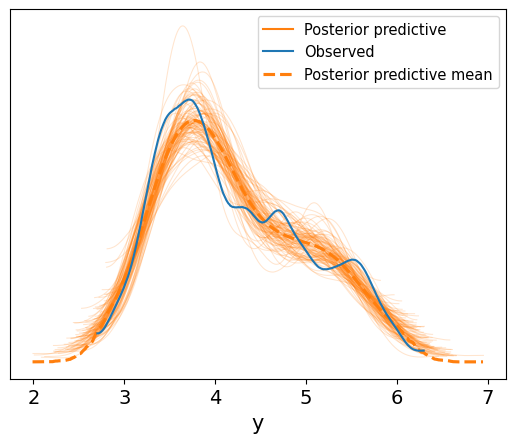

In [20]:
az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [21]:
posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


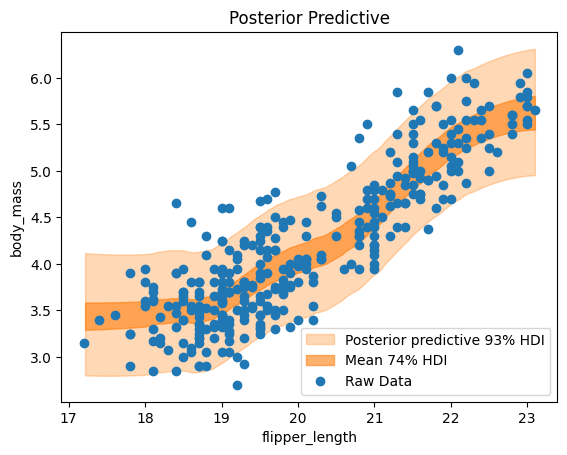

In [26]:
idx = np.argsort(X.to_numpy()[:, 0]) #grab first row
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 0],#grab first row
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive 93% HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 0],#grab first row
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean 74% HDI"},
)
ax.plot(penguins['flipper_length'], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

**I like it because it seems to show a general trend of when flipper length increases, body mass increases as well. This is seen through the mean HDI.**

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

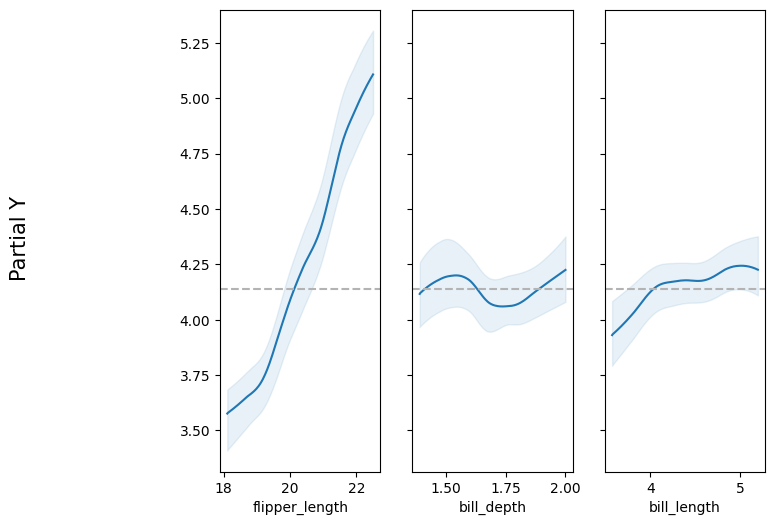

In [27]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

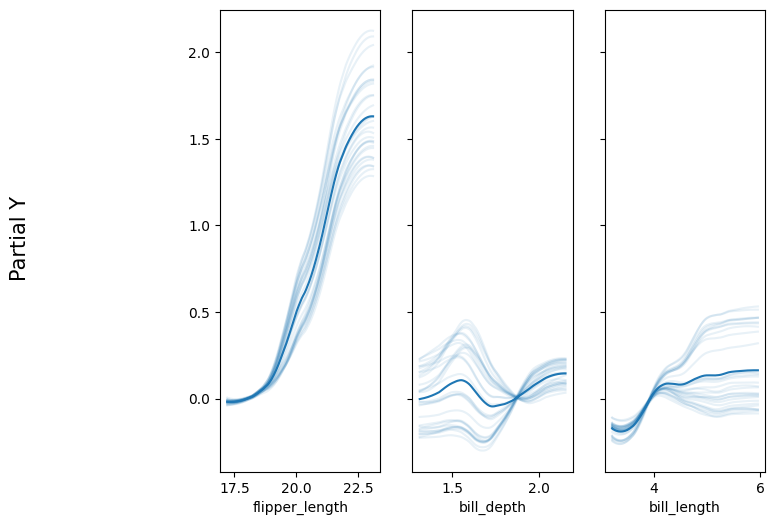

In [28]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [29]:
vi_penguins = pmb.compute_variable_importance(idata_penguins, μ_, X)

<Axes: ylabel='R²'>

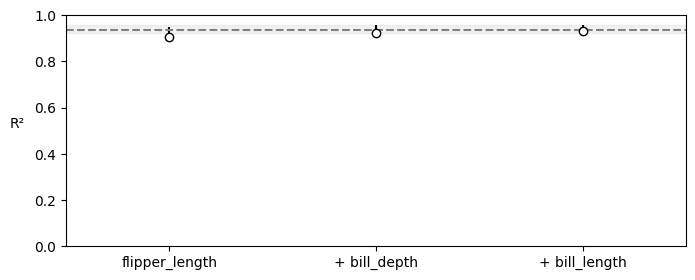

In [30]:
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

**Flipper length seems to be far the most important variable as adding bill depth and bill length doesn't improve the R^2 value. In addition, it has the most linear correlation to body mass of the three variables.**